# JSB Chorales: Exploratory Data Analysis

This notebook loads Johann Sebastian Bach's chorale harmonizations from the **music21** corpus, encodes each of the four SATB voices as `(pitch, duration)` sequences (with rests handled explicitly), and explores basic dataset statistics.

## Dataset context

The **JSB Chorales** are four-voice Lutheran hymn harmonizations by J.S. Bach, widely used in symbolic music modeling (e.g., harmonization, voice-leading analysis, and sequence models). The music21 corpus includes **371** chorales indexed by the Riemenschneider numbering system. Each piece is stored as MusicXML with labeled **Soprano, Alto, Tenor, and Bass** parts.

We encode each voice independently as a sequence of tuples:
- **pitch**: MIDI note number for sounding notes, or `None` for rests
- **duration**: length in quarter-note units (`quarterLength` in music21)

In [1]:
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from music21 import chord, corpus, note

sns.set_theme(style="whitegrid")
VOICE_NAMES = ["Soprano", "Alto", "Tenor", "Bass"]

ModuleNotFoundError: No module named 'seaborn'

## Encoding functions

`encode_part` walks each voice in temporal order and extracts `(pitch, duration)` pairs from notes and rests. Chords (rare in this corpus) are encoded using their highest sounding pitch.

In [3]:
def encode_part(part):
    """Convert one voice into a list of (pitch, duration) tuples.

    pitch is an int MIDI value for notes, or None for rests.
    duration is in quarter-note units.
    """
    sequence = []
    for element in part.flat.notesAndRests:
        duration = float(element.quarterLength)
        if isinstance(element, note.Note):
            sequence.append((element.pitch.midi, duration))
        elif isinstance(element, note.Rest):
            sequence.append((None, duration))
        elif isinstance(element, chord.Chord):
            sequence.append((element.pitches[-1].midi, duration))
    return sequence


def encode_chorale(score):
    """Return four voice sequences for a SATB chorale score."""
    return [encode_part(part) for part in score.parts]


def voice_name(part, index):
    return part.partName or part.id or VOICE_NAMES[index]

## Load and parse all chorales

In [4]:
encoded_chorales = []
metadata = []
skipped = []

for rk_number, score in enumerate(corpus.chorales.Iterator(returnType="stream"), start=1):
    if len(score.parts) != 4:
        skipped.append({
            "riemenschneider": rk_number,
            "title": score.metadata.title,
            "num_parts": len(score.parts),
        })
        continue

    voices = encode_chorale(score)
    encoded_chorales.append(voices)
    metadata.append({
        "riemenschneider": rk_number,
        "title": score.metadata.title,
        "voice_names": [voice_name(part, i) for i, part in enumerate(score.parts)],
        "sequence_lengths": [len(v) for v in voices],
    })

print(f"Loaded {len(encoded_chorales)} four-voice chorales.")
print(f"Skipped {len(skipped)} pieces without exactly four parts.")
if skipped:
    print("Examples of skipped pieces:")
    for item in skipped[:3]:
        print(f"  RK {item['riemenschneider']}: {item['title']} ({item['num_parts']} parts)")

Loaded 351 four-voice chorales.
Skipped 20 pieces without exactly four parts.
Examples of skipped pieces:
  RK 11: Jesu, nun sei gepreiset (9 parts)
  RK 43: Liebster Gott, wann werd’ ich sterben (5 parts)
  RK 46: Vom Himmel hoch, da komm’ ich her (8 parts)


## Sample encoded sequences

Below are the first 12 events from each voice of the first chorale. Rests appear as `(None, duration)`.

In [5]:
sample_idx = 0
sample_meta = metadata[sample_idx]
sample_voices = encoded_chorales[sample_idx]

print(f"Chorale RK {sample_meta['riemenschneider']}: {sample_meta['title']}")
print()

for voice_label, sequence in zip(sample_meta["voice_names"], sample_voices):
    preview = sequence[:12]
    print(f"{voice_label} (len={len(sequence)}): {preview}")

Chorale RK 1: Aus meines Herzens Grunde

Soprano (len=46): [(67, 1.0), (67, 2.0), (74, 1.0), (71, 1.5), (69, 0.5), (67, 1.0), (67, 1.5), (69, 0.5), (71, 1.0), (69, 2.0), (71, 1.0), (74, 2.0)]
Alto (len=61): [(62, 1.0), (62, 1.0), (64, 1.0), (62, 1.0), (62, 2.0), (59, 1.0), (64, 0.5), (62, 0.5), (64, 0.5), (66, 0.5), (67, 1.0), (66, 2.0)]
Tenor (len=59): [(59, 1.0), (59, 1.0), (60, 0.5), (59, 0.5), (57, 1.0), (55, 1.0), (54, 1.0), (55, 1.0), (60, 0.5), (59, 0.5), (60, 1.0), (62, 1.0)]
Bass (len=63): [(43, 1.0), (55, 1.0), (52, 1.0), (54, 1.0), (55, 1.0), (50, 1.0), (52, 1.0), (48, 1.0), (47, 0.5), (45, 0.5), (43, 1.0), (50, 2.0)]


In [6]:
# Find a chorale containing rests for illustration
rest_example = None
for i, voices in enumerate(encoded_chorales):
    if any(pitch is None for voice in voices for pitch, _ in voice):
        rest_example = i
        break

if rest_example is not None:
    meta = metadata[rest_example]
    print(f"Example with rests — RK {meta['riemenschneider']}: {meta['title']}")
    for voice_label, sequence in zip(meta["voice_names"], encoded_chorales[rest_example]):
        rest_events = [(pitch, dur) for pitch, dur in sequence if pitch is None]
        if rest_events:
            print(f"  {voice_label}: {rest_events[:5]}")

Example with rests — RK 6: Christus, der ist mein Leben
  spine_3: [(None, 1.0)]
  spine_2: [(None, 1.0)]
  spine_1: [(None, 1.0)]
  spine_0: [(None, 1.0)]


## Aggregate statistics

In [7]:
all_pitches = []
all_durations = []
piece_lengths = []
voice_ranges = {name: [] for name in VOICE_NAMES}
rest_count = 0
note_count = 0

for meta, voices in zip(metadata, encoded_chorales):
    piece_lengths.append(max(meta["sequence_lengths"]))
    for voice_label, sequence in zip(meta["voice_names"], voices):
        canonical = voice_label.capitalize()
        if canonical not in voice_ranges:
            voice_ranges[canonical] = []
        sounding = [pitch for pitch, _ in sequence if pitch is not None]
        if sounding:
            voice_ranges[canonical].extend(sounding)
        for pitch, duration in sequence:
            all_durations.append(duration)
            if pitch is None:
                rest_count += 1
            else:
                note_count += 1
                all_pitches.append(pitch)

print(f"Total encoded events: {note_count + rest_count:,}")
print(f"  Notes: {note_count:,}")
print(f"  Rests: {rest_count:,} ({100 * rest_count / (note_count + rest_count):.2f}%)")
print(f"Unique pitch values: {len(set(all_pitches))}")
print(f"Unique durations: {len(set(all_durations))}")
print(f"Piece length (max voice events): min={min(piece_lengths)}, max={max(piece_lengths)}, mean={np.mean(piece_lengths):.1f}")

Total encoded events: 82,046
  Notes: 81,282
  Rests: 764 (0.93%)
Unique pitch values: 46
Unique durations: 11
Piece length (max voice events): min=28, max=283, mean=65.0


## Exploratory plots

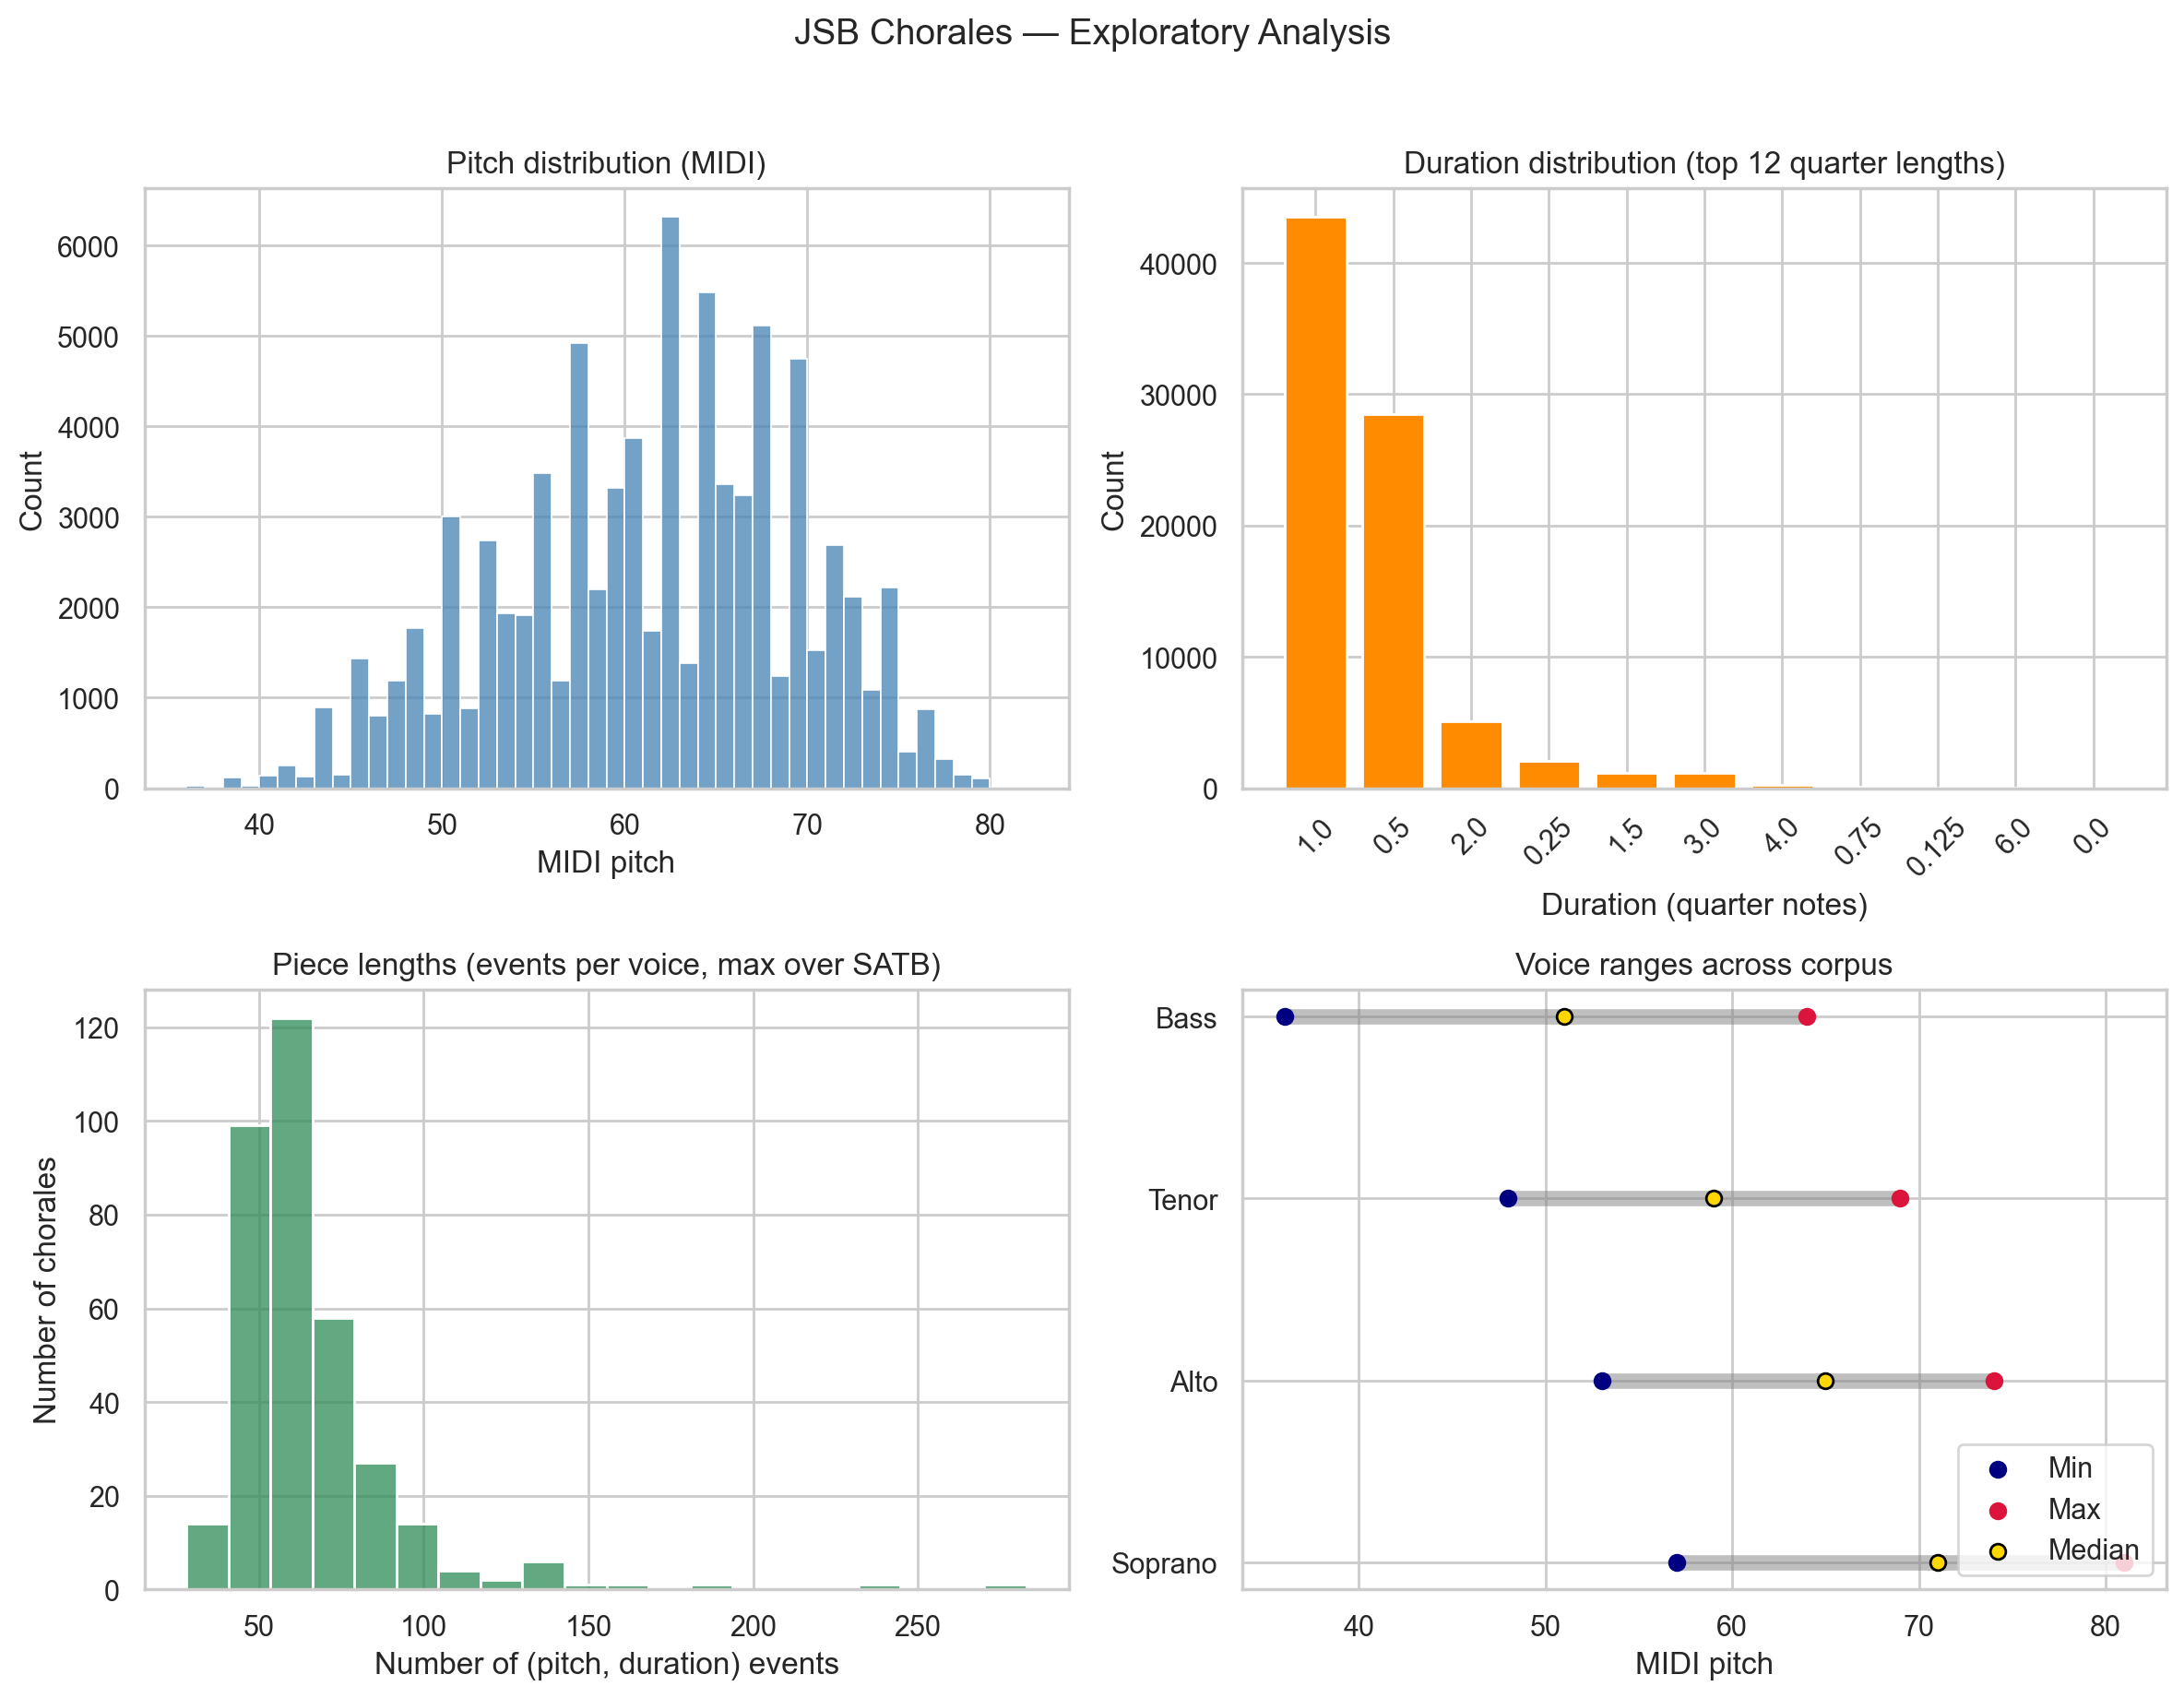

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("JSB Chorales — Exploratory Analysis", fontsize=14, y=1.02)

# 1. Pitch distribution (all voices combined)
ax = axes[0, 0]
sns.histplot(all_pitches, bins=range(min(all_pitches), max(all_pitches) + 2), ax=ax, color="steelblue")
ax.set_title("Pitch distribution (MIDI)")
ax.set_xlabel("MIDI pitch")
ax.set_ylabel("Count")

# 2. Duration distribution
ax = axes[0, 1]
duration_counts = Counter(all_durations)
common_durations = sorted(duration_counts.items(), key=lambda x: (-x[1], x[0]))[:12]
durs, counts = zip(*common_durations)
ax.bar([str(d) for d in durs], counts, color="darkorange")
ax.set_title("Duration distribution (top 12 quarter lengths)")
ax.set_xlabel("Duration (quarter notes)")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)

# 3. Piece lengths
ax = axes[1, 0]
sns.histplot(piece_lengths, bins=20, ax=ax, color="seagreen")
ax.set_title("Piece lengths (events per voice, max over SATB)")
ax.set_xlabel("Number of (pitch, duration) events")
ax.set_ylabel("Number of chorales")

# 4. Voice ranges
ax = axes[1, 1]
range_data = []
for voice in VOICE_NAMES:
    pitches = voice_ranges.get(voice, [])
    if pitches:
        range_data.append({
            "Voice": voice,
            "Min": min(pitches),
            "Max": max(pitches),
            "Median": int(np.median(pitches)),
        })

voices = [row["Voice"] for row in range_data]
mins = [row["Min"] for row in range_data]
maxs = [row["Max"] for row in range_data]
medians = [row["Median"] for row in range_data]
y_pos = np.arange(len(voices))
ax.hlines(y_pos, mins, maxs, color="gray", linewidth=6, alpha=0.5)
ax.scatter(mins, y_pos, color="navy", label="Min", zorder=3)
ax.scatter(maxs, y_pos, color="crimson", label="Max", zorder=3)
ax.scatter(medians, y_pos, color="gold", edgecolor="black", label="Median", zorder=4)
ax.set_yticks(y_pos, voices)
ax.set_xlabel("MIDI pitch")
ax.set_title("Voice ranges across corpus")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

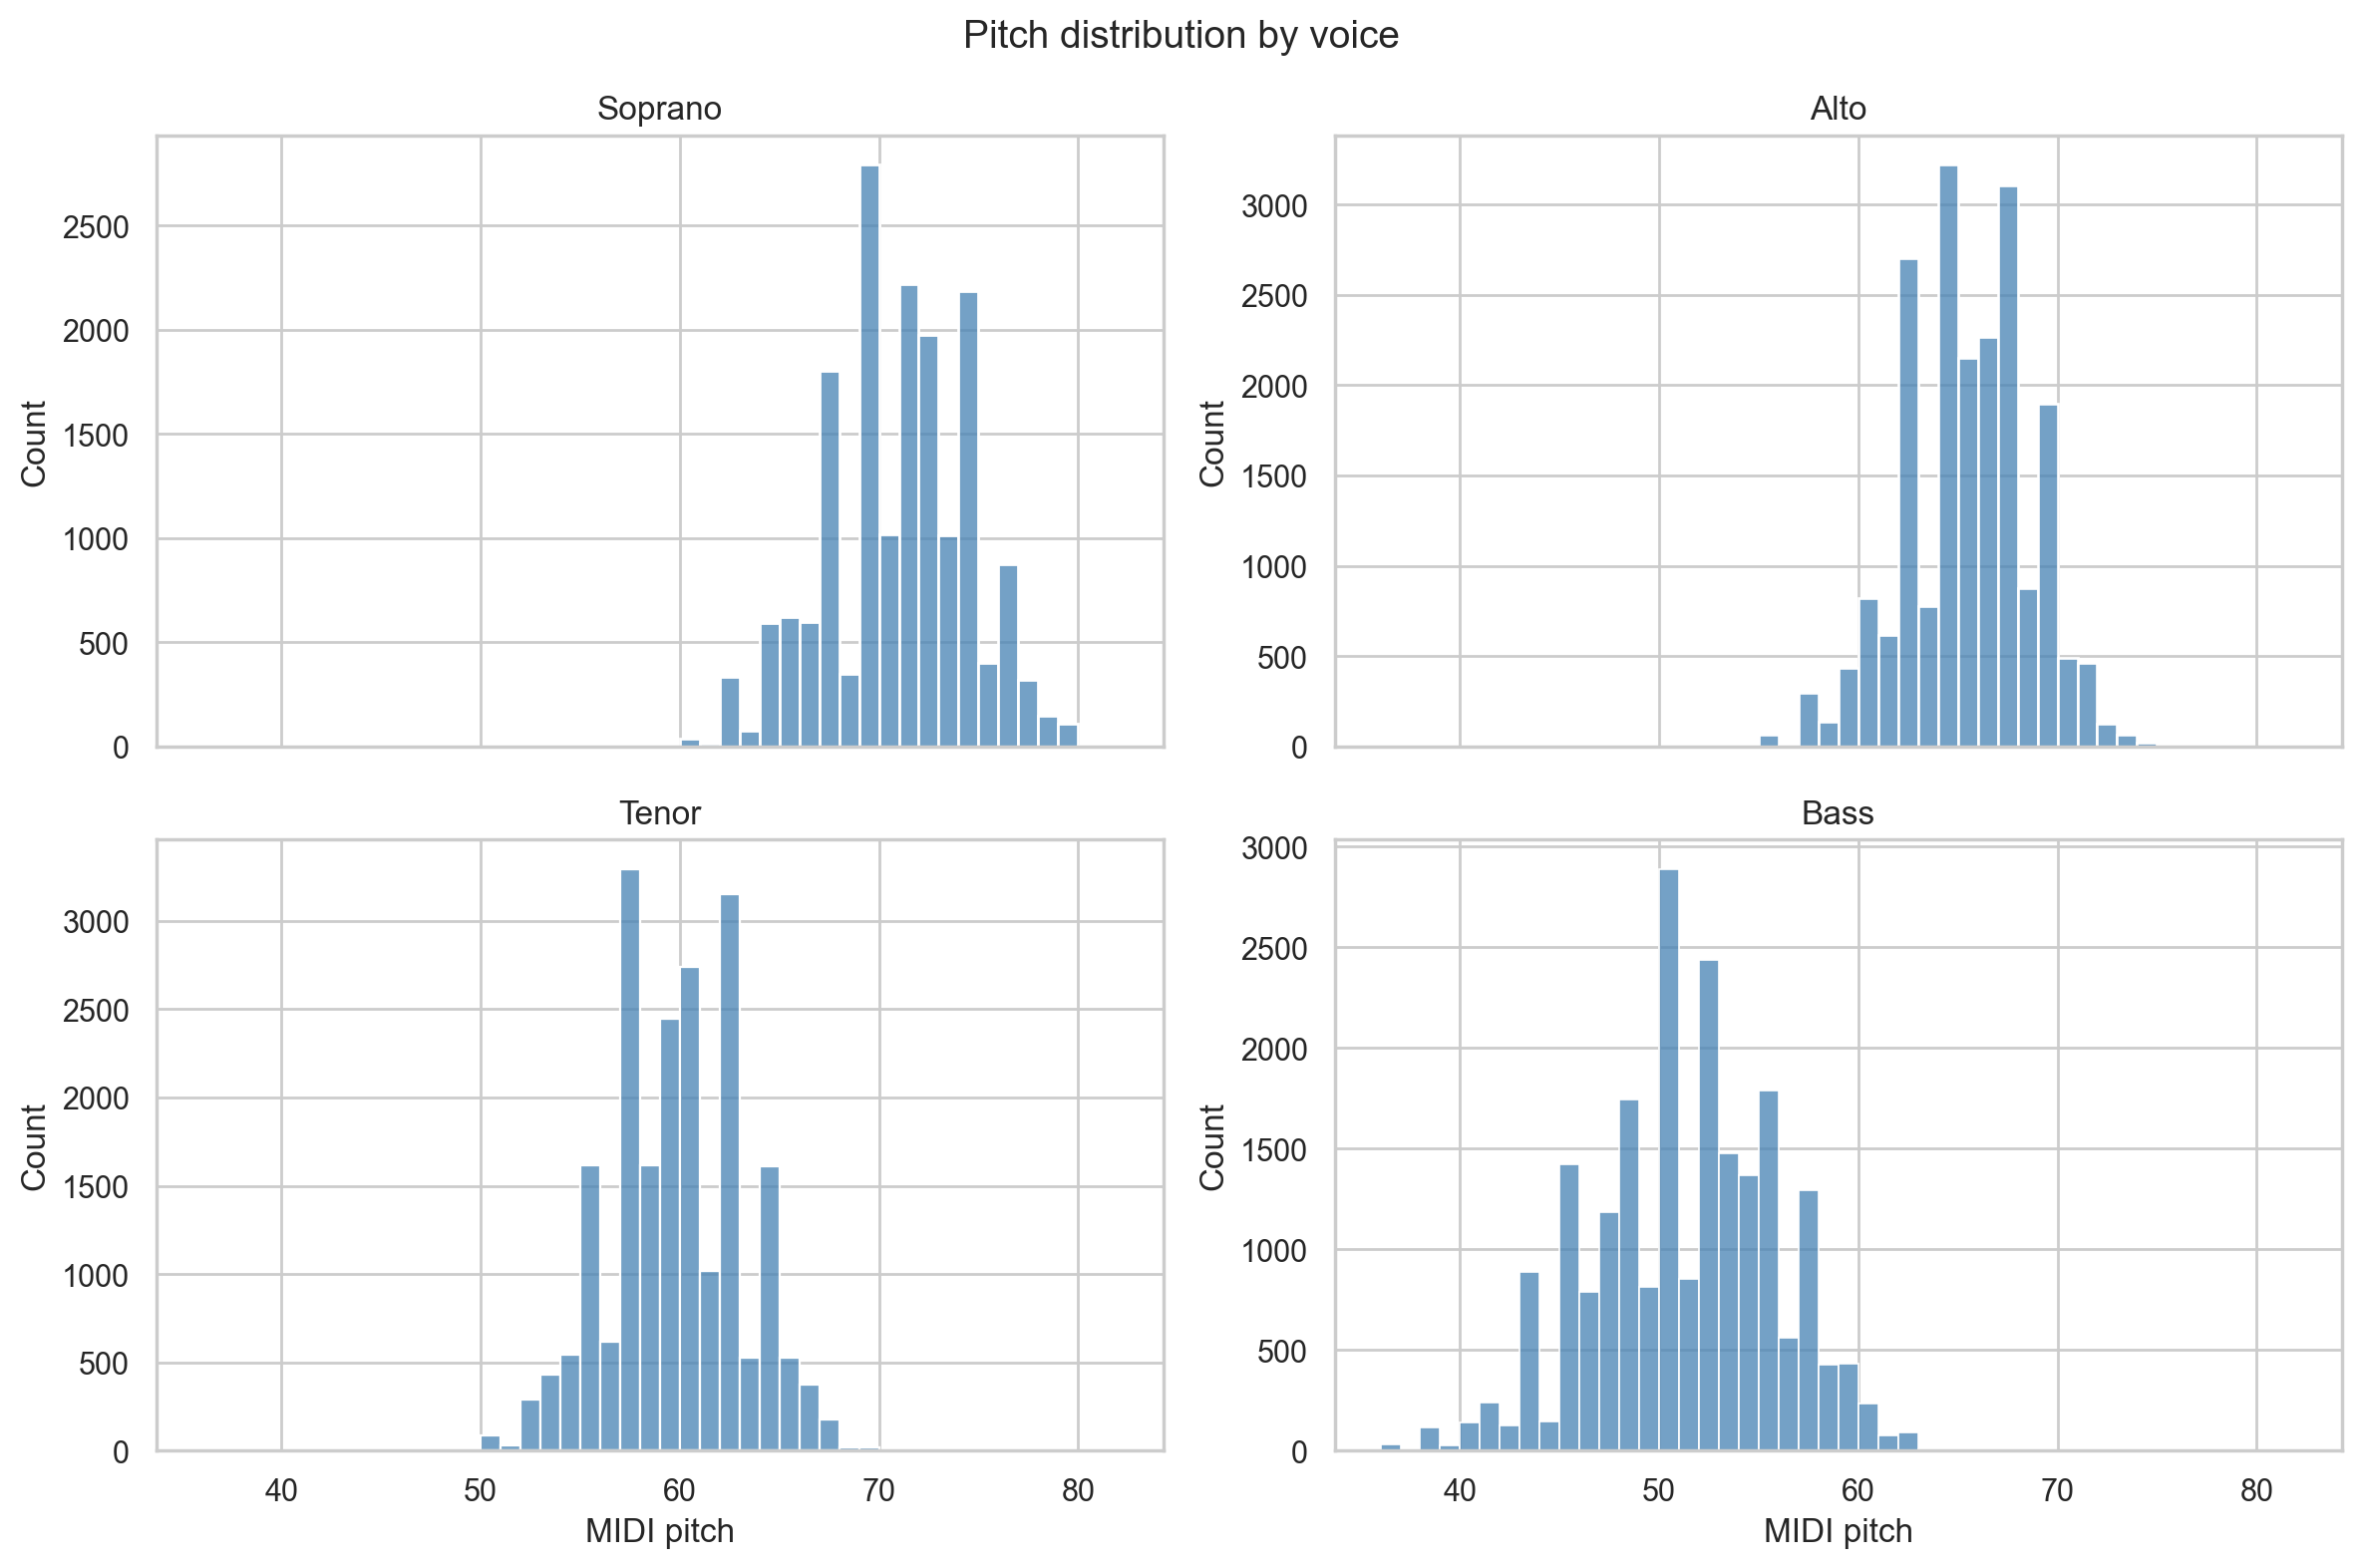

In [9]:
# Per-voice pitch distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
fig.suptitle("Pitch distribution by voice", fontsize=14)

for ax, voice in zip(axes.flat, VOICE_NAMES):
    pitches = voice_ranges.get(voice, [])
    sns.histplot(pitches, bins=range(min(pitches), max(pitches) + 2), ax=ax, color="steelblue")
    ax.set_title(voice)
    ax.set_xlabel("MIDI pitch")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Summary

- Loaded **351** four-voice Bach chorales from the music21 corpus.
- Each voice is represented as a `(pitch, duration)` sequence; rests use `None` for pitch.
- Durations are measured in quarter-note units, matching music21's native representation.
- Pitch and duration distributions, piece lengths, and SATB ranges provide a baseline for later modeling (e.g., Markov chains or neural sequence models).